In [1]:
from observations import Observations
from models_physical import VdP


obs = Observations(model=VdP, 
                    t_start=2.0, 
                    t_stop=2.5, 
                    Nt_obs=50, 
                    add_noise=True,
                    Nq=2,
                    noise_type='gauss, add',
                    noise_level=0.1,
                    manual_bias='linear'
                    )


...Applying manual bias: linear
...Adding noise: gauss, add with level 0.1.
OK: Observations initialized.


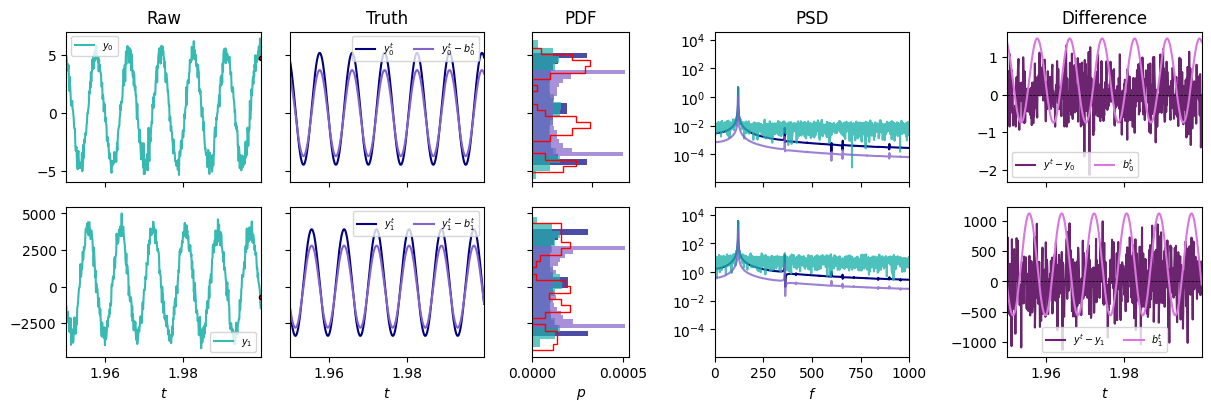

In [2]:

Observations.plot_truth(obs, f_max=1000, window=.05)

We want to model the truth $y^{true}$ using a reduced order model, which may be biased. In this twin experiment case, the ROM is  show in the figure above as $y^{true}-b^{true}$.


To infer the bias $b^{true}$ from the obsdervation data $d$ (red dots) without knowing the truth $y^{true}$, we need to make some assumtions. First, we will assume that we have a model of the system which gives some estimate of the system as 
$$
y^{rom}(t) = y^{true}(t) + b^{true}(t) + \varepsilon_y
$$
and the observations 
$$
d(t^{obs}) = y^{true}(t^{obs}) + \varepsilon_{obs}, 
$$
where $\varepsilon$ is noise. 

In [3]:
from bias_estimators import ESN_bias
from utils import set_working_directories 
from pathlib import Path

# First, initialize a ROM 
rom = VdP(Nq=2
    )


results_dir = set_working_directories('VdP')[1]

training_data_filename = Path(results_dir) / 'Tutorial_05_bias_training_data2_b'


# Then, initialize a Bias object using the ROM and the Observations
bias = ESN_bias(rom=rom,
                reference_data=obs,
                t_min=0.5,
                t_max=2.0,
                training_data_filename=training_data_filename,
                # Parameters for training data generation (if no file found or loading fails)
                std_phi=0.1,
                std_alpha=0.1,
                biased_observations=False,
                # Other parameters for the bias model can be added here as needed
                N_units=50,
                auto_save=True,
                N_func_evals=20,
                N_grid=4,
                t_train=0.2, 
                t_val=0.02,
                upsample=4,
                N_ens=20
                )


✓ Found matching config: dfb948d8e26f1930
Configuration loaded from ...config/esn_configs/dfb948d8e26f1930/esn_config.yaml


AssertionError: Bias state shape (52, 20) does not match expected N_dim = 2.

In [ ]:
bias.print_bias_parameters()


 ---------------- Bias model parameters --------------- 
	 Bias class name: ESN_bias
	 L = 1
	 augment_data_length = 2
	 bayesian_update = False
	 biased_observations = False
	 upsample = 4
	 Model class name: ESN_model
	 N_units = 50
	 N_wash = 5
	 rho = 0.2463933300022686
	 sigma_in = 1.7186020455939544
	 update_reservoir = True
	 update_state = True
	 upsample = 4


In [ ]:
# test forecasting the bias
bias.time_integrate(Nt=100)

ValueError: could not broadcast input array from shape (0,20) into shape (50,20)

In [ ]:
psi0 = bias.current_state

bias.forecaster.unbuild_psi(psi0)

(array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]]),
 array([], shape=(0, 20), dtype=float64))

In [ ]:
self = bias.forecaster
u = psi0[:, :self.N_dim]
r = psi0[:, self.N_dim:self.N_dim+self.N_units]

In [ ]:
u.shape, r.shape

((2, 2), (2, 18))